In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [6]:
def json_to_series(text):
    keys, values = zip(*[item for item in text['data'].items()])
    return pd.Series(values, index=keys)


In [76]:
query = select(Feedback.json).join(Round).filter(
    or_(
        Feedback.key_name=='biohazards',
    ),
    Feedback.datetime >= datetime(2024, 8, 8),
    Feedback.datetime <= datetime(2024, 10, 25),
)

df = pd.read_sql_query(query, session.connection())

In [77]:
df

,json
0,{'data': {'defeated': {'White Terrors': 1}}}
1,{'data': {'defeated': {'Blob': 1}}}
2,{'data': {'defeated': {'Prince Terror': 1}}}
3,{'data': {'defeated': {'White Terrors': 1}}}
4,"{'data': {'survived': {'Queen Terrors': 1}, 'd..."
...,...
202,{'data': {'defeated': {'Green Terrors': 1}}}
203,{'data': {'survived': {'Xenomorphs': 1}}}
204,{'data': {'survived': {'Blob': 1}}}
205,{'data': {'defeated': {'Blob': 1}}}


In [78]:
def biohazards_keys(biohazard_needle):
    def applicator(text):
        fates = defaultdict(int)
        for item in text['data'].items():
            fate = item[0]
            for key in item[1].keys():
                if biohazard_needle in key:
                    fates[fate] += 1
        if not fates:
            return pd.Series()
        keys, values = zip(*fates.items())
        # keys, values = zip(*[1 for item in text['data'].items() if any('Terrors' in x for x in item.keys())])
        return pd.Series(values, index=keys)
    return applicator


In [79]:
terrors = pd.concat([df, df['json'].apply(biohazards_keys('Terrors'))], axis=1).drop(['json'], axis=1)
terrors_filled = terrors.fillna(0).astype(int)
xenos = pd.concat([df, df['json'].apply(biohazards_keys('Xeno'))], axis=1).drop(['json'], axis=1)
xenos_filled = xenos.fillna(0).astype(int)
blobs = pd.concat([df, df['json'].apply(biohazards_keys('Blob'))], axis=1).drop(['json'], axis=1)
blobs_filled = blobs.fillna(0).astype(int)

In [80]:
data = defaultdict(dict)
data['Terrors'] = terrors_filled.sum()
data['Xenomorphs'] = xenos_filled.sum()
data['Blob'] = blobs_filled.sum()

In [81]:
data

defaultdict(dict,
            {'Terrors': defeated    42
             survived    22
             dtype: int64,
             'Xenomorphs': defeated    37
             survived    31
             dtype: int64,
             'Blob': defeated    31
             survived    38
             dtype: int64})

In [97]:
blobs_filled.sum()

defeated    31
survived    38
dtype: int64

In [94]:
xenos_filled.sum()

defeated    37
survived    31
dtype: int64

In [93]:
terrors_filled.sum()

defeated    42
survived    22
dtype: int64

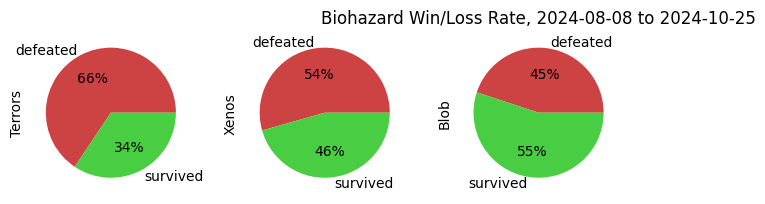

In [96]:
fig, axes = plt.subplots(nrows=1, ncols=3)
plt.title("Biohazard Win/Loss Rate, 2024-08-08 to 2024-10-25", ha='center')
data['Terrors'].plot(ax=axes[0], kind='pie', autopct='%1.0f%%', colors=["#cd4242", "#49cd42"], label='Terrors')
data['Xenomorphs'].plot(ax=axes[1], kind='pie', autopct='%1.0f%%', colors=["#cd4242", "#49cd42"], label='Xenos')
data['Blob'].plot(ax=axes[2], kind='pie', autopct='%1.0f%%', colors=["#cd4242", "#49cd42"], label='Blob')

fig.tight_layout()
plt.savefig('biohazard_winrate_2024-08-08_2024-10-25.png')